# Theoretical background on the development of numerical solver code for 2D-YSYK strange metal model

*For new paper purposes* 

April $1^{\mathrm{st}}$, 2026

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from new_source_files.new_SYK_fft import *
from new_source_files.new_ConformalAnalytical import *
from matplotlib import rcParams
from matplotlib.lines import Line2D

## Function explanations

---

### new_SYK_fft.py

#### 1. `freq2time`

We implement a discretized version to approximate the real-frequency Fourier transform. The function body is as follows: 

```python
{
    def freq2time(array,M,dt):
        domega = np.pi/(M*dt)
        tMinusM = np.arange(2*M)-M
        omega = np.arange(2*M)
        prefOut = (domega/(2*np.pi))*np.exp(np.pi*j*tMinusM)
        prefIn = np.exp(np.pi*j*omega)

        return prefOut*fft(prefIn*array)
}
```

The function takes in three arguments: `array`, `M`, and `dt`. The `array` object is an array-type object evaluated at the different points of the frequency grid, which is assumed to be an approximation of $2M$ points around $\omega = 0$ of the real line:
```python
{
array = [x[0],x[1],x[2],...,x[2*M-1]]
}
```

By recalling the definition of the `np.fft()` function, the resulting array is given by the following:
$$
\begin{gather*}
x[j]=\frac{\mathrm{d}\omega}{2\pi}e^{\pi i(j-M)}\sum_{n=0}^{2M-1}\left(\hat{x}[n]e^{\pi in}\right)e^{-2\pi i\frac{nj}{2M}}=\frac{\mathrm{d}\omega}{2\pi}\sum_{n=0}^{2M-1}\hat{x}[n]e^{-2\pi i\frac{n-M}{2M}(j-M)}=\frac{\mathrm{d}\omega}{2\pi}\sum_{n=-M}^{M-1}\hat{x}[n+M]e^{-2\pi i\frac{n}{2M}(j-M)}
\end{gather*}
$$

Recall that the array `array` is assumed to be evaluated in the frequency grid, symmetrically generated around $\omega=0$, so the Fourier coefficients that result from the final form of the summation from $n=-M$ to $n = M-1$ can be though of as actually evaluated in said grid of points, rather than the default original grid of points from $n=0$ to $n = 2M-1$. Finally, to approximate the summation as an integral, we implement the dimensionless time and frequency definitions:
$$
\hat{\omega}_n \in \{-M,-M+1,\ldots,0,\ldots,M-2,M-1\}\;,\;\hat{t}_j \in \{-M,-M+1,\ldots,0,\ldots,M-2,M-1\}
$$

These dimensionless variables are defined with respect to an underlying scale of time and frequency, which we implement via the differentials $\mathrm{d}t$ and $\mathrm{d}\omega$ defined as:
$$
\mathrm{d}t\cdot\mathrm{d}\omega = \frac{\pi}{M}\;,\;t \equiv \hat{t}\mathrm{d}t\;,\;\omega \equiv \hat{\omega}\mathrm{d}\omega
$$
As such, the dimensions of time and frequency are set by choosing the units of $\mathrm{d}t$ (seconds, hours, etc...), which then fix the units of $\mathrm{d}\omega$. Therefore, in the back of our heads, we have to think of these two diferentials as dimensionful quantities. This gives:
$$
x[\hat{t}_j]\equiv x(t_j) = \frac{\mathrm{d}\omega}{2\pi}\sum_{\hat{\omega}_n=-M}^{M-1}\hat{x}[\hat{\omega}_n]e^{-i\hat{\omega}_n\hat{t}_j\frac{\pi}{M}}\underbrace{\longrightarrow}_{M\to\infty}\int_{-\infty}^{\infty}\!\frac{\mathrm{d}\omega}{2\pi}\,\hat{x}(\omega)e^{-i\omega t_j}
$$

Therefore, in the system of units that the user chooses, the return result of `freq2time` is an array of points evaluated on a time grid centered around $t=0$ that is an approximation of the function:
$$
x(t)=\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega}{2\pi}\,\hat{x}(\omega)e^{-i\omega t}
$$

#### 2. `time2freq`

This is the inverse of the previous function, which is meant to calculate a discrete approximation of the inverse continous Fourier transform from time to frequency space. The function's body is the following:

```python
{
    def time2freq(array,M,dt):
        omegaMinusM = np.arange(2*M)-M
        t = np.arange(2*M)
        prefOut = 2*M*dt*np.exp(-np.pi*j*omegaMinusM)
        prefIn = np.exp(-np.pi*j*t)

    return prefOut*ifft(prefIn*array)
}

```

Again, the inputs of this function are: `array`, `M` and `dt`. The `array` argument is an array object of $2M$ entries (with $M$ a large integer), which corresponds to the values of the function to be Fourier transformed, evaluated in the different points of the time grid, which has $2M$ points centered around $t=0$:
```python
{
    array = [x[0],x[1],x[2],...,x[2*M-1]]
}
```

As in the previous case, the elements of the resulting array arise from the definition of the inverse Fourier transform:
$$
\begin{gather*}
\hat{x}[n]=(2M\mathrm{d}te^{-\pi i(n-M)})\frac{1}{2M}\sum_{j=0}^{2M-1}(x[j]e^{-\pi ij})e^{2\pi i\frac{j}{2M}n}=\mathrm{d}t\sum_{j=-M}^{M-1}x[j+M]e^{2\pi i\frac{j}{2M}(n-M)}
\end{gather*}
$$

Once again we define the dimensionless times and frequencies:
$$
\hat{\omega}_n \in \{-M,-M+1,\ldots,0,\ldots,M-2,M-1\}\;,\;\hat{t}_j \in \{-M,-M+1,\ldots,0,\ldots,M-2,M-1\},
$$
which measure time and frequency in terms of units of a standard unit measurement given by the diferential $\mathrm{d}t$ and its inverse $\mathrm{d}\omega$. With that in mind, the inverse Fourier transform results in the Fourier coefficients:
$$
\hat{x}[\hat{\omega}_n]\equiv\hat{x}[\omega_n]=\mathrm{d}t\sum_{j=-M}^{M-1}x[t_j]e^{i\hat{\omega}_n\hat{t}_j\frac{\pi}{M}}\underbrace{\longrightarrow}_{M\to\infty}\int_{-\infty}^\infty\!\mathrm{d}t\,x(t)e^{i\omega t}
$$

Therefore, the result is a discrete approximation, in the chosen unit system, of the inverse Fourier transform:
$$
\hat{x}(\omega) = \int_{-\infty}^{\infty}\!\mathrm{d}t\,x(t)e^{i\omega t}
$$

#### 3. `fermidirac`

This routine returns the Fermi-Dirac function evaluated at some energy.

In [ ]:
plt.figure(figsize=(10,5))
plt.grid(True)
plt.xlabel(r'$\beta(\epsilon - \mu)$')
plt.ylabel(r'$n_{-1}(\beta(\epsilon-\mu))$')

for beta in [0.05,0.1,0.15,0.5,1]:
    arg = np.arange(-100,100,0.1)*beta
    function = fermidirac(arg)
    domain = np.linspace(-100,100,num = len(arg))
    plt.plot(domain, function, label=rf'$\beta$ = {beta}')

def step_function(x):
    return np.where(x<0,1,0)

plt.plot(domain, step_function(domain), label=r'\beta=\infty', linestyle = 'dashed', color = 'black')
plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show() 

#### 4. `boseeinstein`

This routine returns the Bose-Einstein statistics function evaluated at some energy.

In [ ]:
plt.figure(figsize=(10,5))
plt.grid(True)
plt.xlabel(r'$\beta(\epsilon -\mu)$')
plt.ylabel(r'$n_{+1}(\beta(\epsilon-\mu))$')

for beta in [0.0001,0.1,0.15,0.5,1]:
    domain = np.arange(1/beta,5,0.1)*beta #we will stay above the Bose-Einstein condensation point
                                            #by assuming that the chemical potential remains non-zero
    function = boseeinstein(domain)
    plt.plot(domain, function, label=rf'$\beta$ = {beta}')
    plt.legend(loc = 'upper right')

plt.tight_layout()
plt.show()

### new_ConformalAnalytical.py

#### 1. `rho2sigma2DNormal`

This routine takes in the spectral functions of bosons and fermions for our 2D system and spits out the corresponding retarded self-energies for each, evalauted in real-frequency space. To understand the function's body, though, we first have to look at the Schwinger-Dyson eqiations themselves. We start by the definition of the thermal self-energy for fermions evaluated in Matsubara frequency space. Recall from the theory section that the Schwinger-Dyson equations in the case where the Yukawa coupling incorporates spatial randomness simplifies the spatial dependence of the equations:
$$
\Sigma(i\omega_n)=v^2G(i\omega_n)+\frac{(g')^2}{\beta}\sum_{\nu_m} G(i\omega_n-i\nu_m)D(i\nu_m),
$$
where we denote $\omega_n = (2n+1)\pi/\beta$ and $\nu_m = 2\pi m/\beta$ for the fermionic and bosonic Matsubara frequencies, respectively. Recall that in order to obtain the retarded self-energies and correlators from the thermal correlators, we have to perform analytic continuation from above the complex $\omega$-plane: $i\omega_n\mapsto \omega+i\eta^{+}$. In order to do this, we have introduce the relation between the thermal Green's functions and their corresponding spectral functions, given by:
$$
G(i\omega_n)=\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\frac{\rho_F(\mathbf{x}=\mathbf{0},\omega')}{i\omega_n-\omega'}\;,\;D(i\nu_n)=\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\frac{\rho_B(\mathbf{x}=\mathbf{0},\omega')}{i\nu_n-\omega'}.
$$
Once again, to simplify notation, we denote $\rho_{F/B}(\omega)\equiv\rho_{F/B}(\mathbf{x}=\mathbf{0},\omega)$. Now we introduce these relations into the Schwinger-Dyson equation for the self-energy:

$$
\begin{gather*}
\Sigma(i\omega_n)=v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,\frac{\rho_F(\omega')}{i\omega_n-\omega'}+\frac{(g')^2}{\beta}\sum_{\nu_m}\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,\frac{\rho_F(\omega')}{i\omega_n-i\nu_m-\omega'}\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,\frac{\rho_B(\omega')}{i\nu_m-\omega'}\right]\\
=v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,\frac{\rho_F(\omega')}{i\omega_n-\omega'}+\frac{(g')^2}{\beta}\iint\!\frac{\mathrm{d}\omega\mathrm{d}\omega'}{(2\pi)^2}\rho_F(\omega)\rho_B(\omega')\sum_{\nu_m}\frac{1}{(i\omega_n-i\nu_m-\omega)(i\nu_m-\omega')}
\end{gather*}
$$

The second term in the last step can be expanded by partial fraction decomposition and evaluated using Matsubara sums:
$$
\begin{gather*}
\sum_{\nu_m}\frac{1}{(i\omega_n-i\nu_m-\omega)(i\nu_m-\omega')}=\frac{1}{i\omega_n-(\omega+\omega')}\sum_{\nu_m}\left(\frac{1}{i\omega_n-i\nu_m-\omega}+\frac{1}{i\nu_m-\omega'}\right)=\frac{1}{i\omega_n-(\omega+\omega')}\left(\sum_{\nu_m}\frac{1}{i\nu_m-\omega'}-\sum_{\nu_m}\frac{1}{i\nu_m-i\omega_n+\omega}\right)\\
=\frac{\beta}{i\omega_n-(\omega+\omega')}\left(-\frac{1}{e^{\beta\omega'}-1}+\frac{1}{e^{\beta(i\omega_n-\omega)-1}}\right)=\frac{\beta}{i\omega_n-(\omega+\omega')}\left(\frac{1}{e^{\beta i\omega_n}e^{-\beta\omega}-1}-\frac{1}{e^{\beta\omega'}-1}\right)=-\frac{\beta}{i\omega_n-(\omega+\omega')}\left(\frac{1}{e^{-\beta\omega}+1}+\frac{1}{e^{\beta\omega'}-1}\right)\\
=-\frac{\beta[\,n_{FD}(-\beta\omega)+n_{BE}(\beta\omega')\,]}{i\omega_n-(\omega+\omega')}
\end{gather*}
$$

Plugging this into our expression for the self-energy:
$$
\begin{equation*}
\Sigma(i\omega_n)=v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,\frac{\rho_F(\omega')}{i\omega_n-\omega'}-(g')^2\iint\!\frac{\mathrm{d}\omega\mathrm{d}\omega'}{(2\pi)^2}\,\rho_F(\omega)\rho_B(\omega')\frac{n_{FD}(-\beta\omega)+n_{BE}(\beta\omega')}{i\omega_n-(\omega+\omega')}
\end{equation*}
$$

Now we are ready to apply analytic continuation through the mapping $i\omega_n\mapsto \omega+i\eta^{+}$. This gives the retarded self-energy in real frequency space:
$$
\begin{align*}
\Sigma_R(\omega)&=v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,\frac{\rho_F(\omega')}{\color{red}\omega-\omega'+i\eta^{+}}-(g')^2\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\!\rho_F(\omega')\rho_B(\omega'')\frac{n_{FD}(-\beta\omega')+n_{BE}(\beta\omega'')}{\color{red}\omega-\omega'-\omega''+i\eta^{+}}\\
&=v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,\rho_F(\omega'){\color{red}\left(i\int_0^\infty\!\mathrm{d}t\,e^{i(\omega-\omega')t}e^{-\eta^{+}t}\right)}-(g')^2\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\!\rho_F(\omega')\rho_B(\omega'')\left[n_{FD}(-\beta\omega')+n_{BE}(\beta\omega'')\right]{\color{red}\left(i\int_{0}^\infty\!\mathrm{d}t\,e^{i(\omega-\omega'-\omega'')t}e^{-\eta^{+}t}\right)}\\
&=i\int_{\color{red}-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}{\color{red}\theta(t)}e^{-\eta^{+}|t|}\left\{v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\rho_F(\omega')-(g')^2\underbrace{\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_B(\omega'')\left[n_{FD}(-\beta\omega')+n_{BE}(\beta\omega'')\right]e^{-i\omega't}e^{-i\omega''t}}_{(*)}\right\}
\end{align*}
$$

We expand the term identified as $(*)$ in the following symmetric manner:
$$
\begin{align*}
(*)&=\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\left(\rho_F(\omega')e^{-i\omega't}\right)\cdot\left(\rho_B(\omega'')e^{-i\omega''t}\right)\left[n_{FD}(-\beta\omega')+n_{BE}(\beta\omega'')\right]\\
&=\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\left(\rho_F(\omega')e^{-i\omega't}\right)\cdot\left(\rho_B(\omega'')e^{-i\omega''t}\right)n_{FD}(-\beta\omega')+\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\left(\rho_F(\omega')e^{-i\omega't}\right)\cdot\left(\rho_B(\omega'')e^{-i\omega''t}\right)n_{BE}(\beta\omega'')\\
&=\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(-\beta\omega')\rho_{F}(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}\rho_B(\omega'')\right)+\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\rho_F(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(\beta\omega'')\rho_B(\omega'')\right)\\
&=\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(-\beta\omega')\rho_{F}(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}\cdot{\color{red}1}\cdot\rho_B(\omega'')\right)+\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\cdot{\color{red}1}\cdot\rho_F(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(\beta\omega'')\rho_B(\omega'')\right)
\end{align*}
$$

We use the identity: $n_{FD}(x)+n_{FD}(-x)=-n_{BE}(x)-n_{BE}(-x)=1$, and plug it into the $1$'s we introduced in the last line:
$$
\begin{align*}
(*)&={\color{red}-}\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(-\beta\omega')\rho_{F}(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}\cdot{\color{red}(n_{BE}(\beta\omega'')+n_{BE}(-\beta\omega''))}\cdot\rho_B(\omega'')\right)\\
&+\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\cdot{\color{red}(n_{FD}(\beta\omega')+n_{FD}(-\beta\omega'))}\cdot\rho_F(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(\beta\omega'')\rho_B(\omega'')\right)\\
&=-\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(-\beta\omega')\rho_{F}(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(\beta\omega'')\cdot\rho_B(\omega'')+\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(-\beta\omega'')\cdot\rho_B(\omega'')\right)\\
&+\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')+\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(-\beta\omega')\rho_F(\omega')\right)\cdot\left(\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(\beta\omega'')\rho_B(\omega'')\right)
\end{align*}
$$

Now we introduce the notation:
$$
\rho_{F/D}^{ss'}(t):=\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega}{2\pi}\,e^{-i\omega t}n_{FD/BE}(s\beta\omega)\rho_{F/B}(s'\omega), 
$$
with $s\in\{-,+\}$. Therefore:
$$
\begin{align*}
(*)&=-\rho_{F}^{-+}(t)[\,\rho_{B}^{++}(t)+\rho_{B}^{-+}(t)\,]+[\,\rho_{F}^{++}(t)+\rho_{F}^{-+}(t)\rho\,]\rho_{B}^{++}(t)=-\rho_{F}^{-+}(t)\rho_{B}^{++}(t)-\rho_{F}^{-+}(t)\rho_{B}^{-+}(t)+\rho_{F}^{++}(t)\rho_{B}^{++}(t)+\rho_{F}^{-+}(t)\rho_{B}^{++}(t)\\
&=\rho_{F}^{++}(t)\rho_{B}^{++}(t)-\rho_{F}^{-+}(t)\rho_{B}^{-+}(t)
\end{align*}
$$

Finally, we plug this expression into the retarded self-energy equation, and utilize the same identity $n_{FD}(x)+n_{FD}(-x)=1$ one final time, yielding:
$$
\begin{align*}
\Sigma_R(\omega)&=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\cdot{\color{red}1}\cdot\rho_F(\omega')-(g')^2\left[\rho_F^{++}(t)\rho_B^{++}(t)-\rho_F^{-+}(t)\rho_B^{-+}(t)\right]\right\}\\
&=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{v^2\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\cdot{\color{red}(n_{FD}(\beta\omega')+n_{FD}(-\beta\omega'))}\cdot\rho_F(\omega')-(g')^2\left[\rho_F^{++}(t)\rho_B^{++}(t)-\rho_F^{-+}(t)\rho_B^{-+}(t)\right]\right\}\\
&=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{v^2\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')+\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(-\beta\omega')\rho_F(\omega')\right]-(g')^2\left[\rho_F^{++}(t)\rho_B^{++}(t)-\rho_F^{-+}(t)\rho_B^{-+}(t)\right]\right\}\\
&=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{v^2\left[\rho_F^{++}(t)+\rho_F^{-+}(t)\right]-(g')^2\left[\rho_F^{++}(t)\rho_B^{++}(t)-\rho_F^{-+}(t)\rho_B^{-+}(t)\right]\right\}
\end{align*}
$$

Therefore, we finally have an expression for the retarded fermionic self energy in time-domain:
$$
\begin{equation*}
\Sigma_R(t)=i\theta(t)e^{-\eta^{+}|t|}\left\{v^2\left[\rho_F^{++}(t)+\rho_F^{-+}(t)\right]-(g')^2\left[\rho_F^{++}(t)\rho_B^{++}(t)-\rho_F^{-+}(t)\rho_B^{-+}(t)\right]\right\}
\end{equation*}
$$

By taking the Fourier transform of this quantity, we obtain the retarded fermionic self-energy in frequency space. Now we have to make the same excercise for the bosonic self-energy, whose Schwinger-Dyson equation reads:
$$
\Pi(i\nu_n)=-\frac{2(g')^2}{\beta}\sum_{\omega_m}G(i\nu_n+i\omega_m)G(i\omega_m),
$$
with the sum over Matsubara frquencies now takign place in fermionic signature. We proceed as we did previously:


$$
\begin{gather*}
\Pi(i\nu_n)=-\frac{2(g')^2}{\beta}\sum_{\omega_m}\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\frac{\rho_F(\omega')}{i\nu_n+i\omega_m-\omega'}\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,\frac{\rho_F(\omega'')}{i\omega_m-\omega''}\right]=-\frac{(g')^2}{\beta}\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_F(\omega'')\sum_{\omega_m}\frac{1}{(i\nu_n+i\omega_m-\omega')(i\omega_m-\omega'')}\\
=-\frac{(g')^2}{\beta}\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_F(\omega'')\frac{1}{\omega'-i\nu_n-\omega''}\sum_{\omega_m}\left(\frac{1}{i\omega_m+i\nu_n-\omega'}-\frac{1}{i\omega_m-\omega''}\right)\\
=(g')^2\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_F(\omega'')\frac{1}{i\nu_n+\omega''-\omega'}\left(\frac{1}{e^{\beta(\omega'-i\nu_n)}+1}-\frac{1}{e^{\beta\omega''}+1}\right)\\
=(g')^2\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_F(\omega'')\frac{1}{i\nu_n+\omega''-\omega'}\left(\frac{1}{e^{\beta\omega'}+1}-\frac{1}{e^{\beta\omega''}+1}\right)=(g')^2\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_F(\omega'')\frac{n_{FD}(\beta\omega')-n_{FD}(\beta\omega'')}{i\nu_n+\omega''-\omega'}
\end{gather*}
$$

$$
\begin{gather*}
\Longrightarrow \Pi_R(\omega)=(g')^2\iint\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\rho_F(\omega')\rho_F(\omega'')\frac{n_{FD}(\beta\omega')-n_{FD}(\beta\omega'')}{\omega+\omega''-\omega'+i\eta^{+}}=(g')^2\iint\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\rho_F(\omega')\rho_F(\omega'')(n_{FD}(\beta\omega')-n_{FD}(\beta\omega''))\left(i\int_0^\infty\!\mathrm{d}t\,e^{i(\omega+\omega''-\omega')t}e^{-\eta^{+}t}\right)\\
=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{(g')^2\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,e^{-i\omega't}e^{i\omega''t}\rho_F(\omega')\rho_F(\omega'')\left[n_{FD}(\beta\omega')-n_{FD}(\beta\omega'')\right]\right\}\\
=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}(g')^2\left\{\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,e^{-i\omega't}e^{i\omega''t}\rho_F(\omega')\rho_F(\omega'')n_{FD}(\beta\omega')-\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,e^{-i\omega't}e^{i\omega''t}\rho_F(\omega')\rho_F(\omega'')n_{FD}(\beta\omega'')\right\}\\
=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}(g')^2\left\{\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{i\omega''t}\rho_F(\omega'')\right]-\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{i\omega''t}n_{FD}(\beta\omega'')\rho_F(\omega'')\right]\right\}\\
=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}(g')^2\left\{\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}(n_{FD}(\beta\omega'')+n_{FD}(-\beta\omega''))\rho_F(-\omega'')\right]\right.\\
\left.-\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}(n_{FD}(\beta\omega')+n_{FD}(-\beta\omega'))\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{FD}(-\beta\omega'')\rho_F(-\omega'')\right]\right\}\\
=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}(g')^2\left\{\rho_F^{++}(t)\cdot\left[\rho_F^{+-}(t)+\rho_F^{--}(t)\right]-\left[\rho_F^{++}(t)+\rho_F^{-+}(t)\right]\rho_F^{--}(t)\right\}\\
=i\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}(g')^2\left[\rho_F^{++}(t)\rho_F^{+-}(t)-\rho_F^{-+}(t)\rho_F^{--}(t)\right]
\end{gather*}
$$

Therefore, we finally have the expression for the retarded bosonic self-energy in time domain:
$$
\Pi_R(t)=i(g')^2\theta(t)e^{-\eta^{+}|t|}\left[\rho_F^{++}(t)\rho_F^{+-}(t)-\rho_F^{-+}(t)\rho_F^{--}(t)\right]
$$

Now we move on to actually create our routine for calculating the retarded self energies when taking the spectral functions of bosons and fermions as input.

#### 2. `rho2sigma0DNormal`

This function takes in the spectral functions of the quantum dot (0+1-dimensional) YSYK model and spits out the corresponding self-energies via the Schwinger-Dyson equations. As is explained in $[5]$ (and as we show in the section titled "Warm-up: Theory explanation for YSYK"), the self-energies in Matsubara frequency space are given by:
$$
\begin{equation*}
\Sigma_\sigma(\omega_n) = \frac{\overline{g}^2}{\beta}\sum_{\omega_m}G_\sigma(\omega_m)D(\omega_n-\omega_m)\;,\;\Pi(\nu_n)=-\frac{2\overline{g}}{\beta}\sum_{\omega_m}G(\omega_m+\nu_n)G(\omega_m)
\end{equation*}
$$

We can express these equations in terms of the spectral functions of fermions and bosons using the same techniques we showed in the previous section for the 2D model (the exact same relations and identities apply). So as not te repeat the exact same procedure, we cite the result for the fermionic self-energy:
$$
\begin{align*}
\Sigma_R(\omega)&=\overline{g}^2\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_B(\omega'')\frac{n_{FD}(\beta\omega')+n_{BE}(-\beta\omega'')}{\omega-\omega'-\omega''+i\eta^{+}}\\
&=i\,\overline{g}^{\,2}\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^{\infty}\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}\rho_B(\omega'')\right]\right.\\
&\left.+\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(-\beta\omega'')\rho_B(\omega'')\right]\right\}\\
&=i\,\overline{g}^{\,2}\int_{-\infty}^\infty\!\mathrm{d}t\,e^{-i\omega t}\theta(t)e^{-\eta^{+}|t|}\left[\rho_F^{-+}(t)\rho_B^{-+}(t)-\rho_F^{++}(t)\rho_B^{++}(t)\right]
\end{align*}
$$

Therefore:
$$
\Sigma_R(t)=i\,\overline{g}^{\,2}\theta(t)e^{-\eta^{+}|t|}\left[\rho_F^{-+}(t)\rho_B^{-+}(t)-\rho_F^{++}(t)\rho_B^{++}(t)\right]
$$

On the other hand, for the bosonic self-energy:
$$
\begin{align*}
\Pi_R(\omega)&=-2\overline{g}^{\,2}\iint\!\frac{\mathrm{d}\omega'\mathrm{d}\omega''}{(2\pi)^2}\,\rho_F(\omega')\rho_F(\omega'')\frac{n_{FD}(\beta\omega'')-n_{FD}(\beta\omega')}{\omega+\omega'-\omega'+i\eta^{+}}\\
&=-2i\,\overline{g}^{\,2}\int_{-\infty}^\infty\!\mathrm{d}t\,e^{-i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{i\omega''t}n_{FD}(\beta\omega'')\rho_F(\omega'')\right]\right.\\
&\left.-\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{i\omega''t}\rho_F(\omega'')\right]\right\}\\
&=-2i\,\overline{g}^{\,2}\int_{-\infty}^\infty\!\mathrm{d}t\,e^{-i\omega t}\theta(t)e^{-\eta^{+}|t|}\left[\rho_F^{-+}(t)\rho_F^{--}(t)-\rho_F^{++}(t)\rho_F^{+-}(t)\right]
\end{align*}
$$

Notice that the global factor of $2$ arises from the spin sum of the fermionic Green's functions, resulting in an overall degeneracy factor of $2s+1 = 2$. Therefore:
$$
\Pi_R(t)=-2i\,\overline{g}^{\,2}\theta(t)e^{-\eta^{+}|t|}\left[\rho_F^{-+}(t)\rho_F^{--}(t)-\rho_F^{++}(t)\rho_F^{+-}(t)\right]
$$

#### 3. `Dav_rho2sigma0DNormal`

This is a different implementation of the routine for calculating the retarded self-energies in the normal phase. Recall from the calculations in the previous section that:

$$
\begin{align*}
\Sigma_R(\omega) &= i\,\overline{g}^{\,2}\int_{-\infty}^\infty\!\mathrm{d}t\,e^{i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^{\infty}\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}\rho_B(\omega'')\right]\right.\\
&\left.+\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{-i\omega''t}n_{BE}(-\beta\omega'')\rho_B(\omega'')\right]\right\}
\end{align*}
$$

The whole point of this different implementation is to stop at this step, and write the self-energy as is expressed in this shape. Same goes for the bosonic self-energy:
$$
\begin{align*}
\Pi_R(\omega) = &=-2i\,\overline{g}^{\,2}\int_{-\infty}^\infty\!\mathrm{d}t\,e^{-i\omega t}\theta(t)e^{-\eta^{+}|t|}\left\{\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{i\omega''t}n_{FD}(\beta\omega'')\rho_F(\omega'')\right]\right.\\
&\left.-\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega'}{2\pi}\,e^{-i\omega't}n_{FD}(\beta\omega')\rho_F(\omega')\right]\cdot\left[\int_{-\infty}^\infty\!\frac{\mathrm{d}\omega''}{2\pi}\,e^{i\omega''t}\rho_F(\omega'')\right]\right\}
\end{align*}
$$

## Warm-up: Theory explanation for YSYK
---

### Normal state equations of motion

As a warm-up we will attempt to reproduce the phase diagram and spectral functions of the quantum dot YSYK model, in order to get a feeling on how all the code works. We start by stating the model's euclidean action as stated in $[5]$:
$$
\begin{align*}
S = \int_0^\beta\!\mathrm{d}\tau\,\sum_{j=1}^N\psi_j^\dagger(\tau)(\partial_\tau-\mu)\psi_j(\tau)+\frac{1}{2}\int_0^\beta\!\mathrm{d}\tau\,\sum_{j=1}^N\phi_j(\tau)(-\partial_\tau^2+\omega_0^2)\phi_j(\tau)+\int_0^\beta\!\mathrm{d}\tau\,\sum_{j,k,l=1}^N\frac{\sqrt{2}g_{jkl}}{N}\psi_j^\dagger(\tau)\psi_k(\tau)\phi_l(\tau)
\end{align*}
$$

The fields $\psi_j$ are $N$-copies of $0+1$-dimensional Dirac spinors (i.e: they are Grassman numbers in the action) under a chemical potential $\mu = 0$ (to be set equal to zero), while the fields $\phi_j$ are also $N$ copies of a real scalar field with (bare) mass $\omega_0^2$ $[5]$. The random coupling constant $g_{jkl}$ are taken from the random Gaussian or Orthogonal Unitary Ensembles, and assumed such that $(g_{jkl})^* = g_{kjl}$ (i.e: $[(g_{jk})_{j,k=1}^{N}]^\dagger_k = [(g_{jk})_{j,k=1}^{N}]_k$), depending on if we want to preserve time reversal symmetry to allow for superconductivity to arise $[5,6]$. For simplicity, we will first supress superconductivity by choosing the Unitary Orthogonal Ensemble when taking averages over the flavor space of the Yukawa coupling. In general, if we expand the coupling constant in real and imaginary parts as $g_{jkl} = g'_{jkl}+ig''_{jkl}$, we have $[6]$:
$$
\begin{align*}
\langle\,g'_{jkl}\,g'_{j'k'l'}\,\rangle_g & = \left(1-\frac{\alpha}{2}\right)\overline{g}^2\delta_{l,l'}(\delta_{j,j'}\delta_{k,k'}+\delta_{j,k'}\delta_{k,j'})\\
\langle\,g''_{jkl}\,g''_{j'k'l'}\,\rangle_g & = \frac{\alpha}{2}\overline{g}^2\delta_{l,l'}(\delta_{j,j'}\delta_{k,k'}-\delta_{j,k'}\delta_{k,j'})\\
\langle\,g'_{jkl}\,g''_{j'k'l'}\,\rangle_g & = 0,
\end{align*}
$$
where $\langle\,\cdot\,\rangle_g$ denotes averaging over the random probability distribution of $g_{jkl}$, and the mean of the real and imaginary parts of $g_{jkl}$ are assumed as zero. When choosing $\alpha = 0$ we see that the imaginary part of $g$ has zero variance, therefore making the coupling constants $g_{jkl}$ real for all members of the random ensemble. If $\alpha = 1$, then time reversal symmetry in the theory's Hamiltonian is destroyed, and we have no superconductivity. We will choose the latter case in order to reproduce all possible quantum critical behavior of the SYK metal without having it supressed by the competing phase of superconductivity at low temperatures $[4]$.

In the above mentioned regime, and in the $N=\infty$ strongly correlated version of the model, we obtain the following Schwinger-Dyson equations for the bosonic and fermionic self-energies and Green's functions $[5]$:
$$
\begin{align*}
\Sigma_\sigma(\omega_n) &= \frac{\overline{g}^2}{\beta}\sum_{\omega_m}G_\sigma(\omega_m)D(\omega_n-\omega_m)\\
\Pi(\nu_n)&=-\frac{2\overline{g}}{\beta}\sum_{\omega_m}G(\omega_m+\nu_n)G(\omega_m)\\
G_\sigma(\omega_n)&=\frac{1}{i\omega_n+\mu-\Sigma_\sigma(\omega_n)}\\
D(\nu_n)&=\frac{1}{\nu_n^2+\omega_0^2-\Pi(\nu_n)}
\end{align*}
$$ 

Here, $G_\sigma$ and $D$ are, respectively, the fermion and boson thermal Green's functions (with the corresponding fermionic spin index $\sigma$), while $\Sigma_\sigma$ and $\Pi$ are the fermion and boson thermal self-energies, respectively. Also, $\omega_n = (2n+1)\pi/\beta$ and $\nu_n = 2n\pi/\beta$ are the fermionic and bosonic Matsubara frequencies.

### Spectral functions in the normal state at various (low) temperatures.

We now try to derive the numerical expressions for the spectral functions of fermions and bosons in the quantum critical SYK-NFL state that the system flows towards at low temperatures $[5]$. We must not fear that superconductivity will mess up our flow towards the quantum critical SYK fixed point. However, we must set first the units convention for our system. The YSYK quantum dot model has two energy scales: $\omega_0$ and $\overline{g}^{2/3}$. Therefore, all energy scales will me measured in units of $\omega_0$, and we will introduce a dimensionless coupling constant $g^2=\overline{g}^{\,2}/\omega_0^3$, as is done in $[5]$.

Also, recall that the "small" adjective in small temperatures is measured relative to the size of the dimensionless coupling $g^2$ that we have introduced, with the quantum critical regime being accessed only when $T/\omega_0\lesssim g^2$ for small $g^2$, and $T/\omega\lesssim g^{-2}$ for large $g^2$ $[5]$. With this in mind, we must go back a little bit in our analysis and consider the units of each member of the Schwinger-Dyson equations. We can do this easily by forcibly introducing the constant $g^2$ that we defined above, and by expressing all energies in terms of $\omega_0$:
$$
\begin{align*}
\omega_0^{-1}\Sigma_\sigma(\omega_n) &= \frac{g^2}{\beta\omega_0}\sum_{\omega_m}\left[\omega_0^2G_\sigma(\omega_m)\right]\left[\omega_0^2D(\omega_n-\omega_m)\right]\\
\omega_0^{-2}\Pi(\nu_n)&=-\frac{g^2}{\beta\omega_0}\sum_{\omega_m}\left[\omega_0G(\omega_m+\nu_n)\right]\left[\omega_0G(\omega_m)\right]\\
\omega_0G_\sigma(\omega_n)&=\frac{1}{i\omega_n/\omega_0+\mu/\omega_0-\omega_0^{-1}\Sigma_\sigma(\omega_n)}\\
\omega_0^{2}D(\nu_n)&=\frac{1}{\nu_n^2/\omega_0^2+1-\omega_0^{-2}\Pi(\nu_n)}
\end{align*}
$$ 

As we can see, the shape of the Schwinger-Dyson equations remains invariant under the re-scaling of energy towards units of $\omega_0$, with the simultaneous mapping $\overline{g}^{\,2}\mapsto g^2$. As such, **all calculations will be performed in this unit system**, which includes the scale of time and frequency.

In [2]:
M = int(2**16) #number of points in the grid
T = 2**13 #upper cut-off for the time (in units of omega0)
err = 1e-4
omega,t  = RealGridMaker(M,T) #grid of time points, in units of omega0
dw = omega[2] - omega[1]
dt = t[2] - t[1]

print("dw = ", dw)
print("dt = ", dt)
print('Maximum frequency: ', np.max(omega))

dw =  0.0003834951969707845
dt =  0.125
Maximum frequency:  25.132357733521374


##### With mid-point rule:

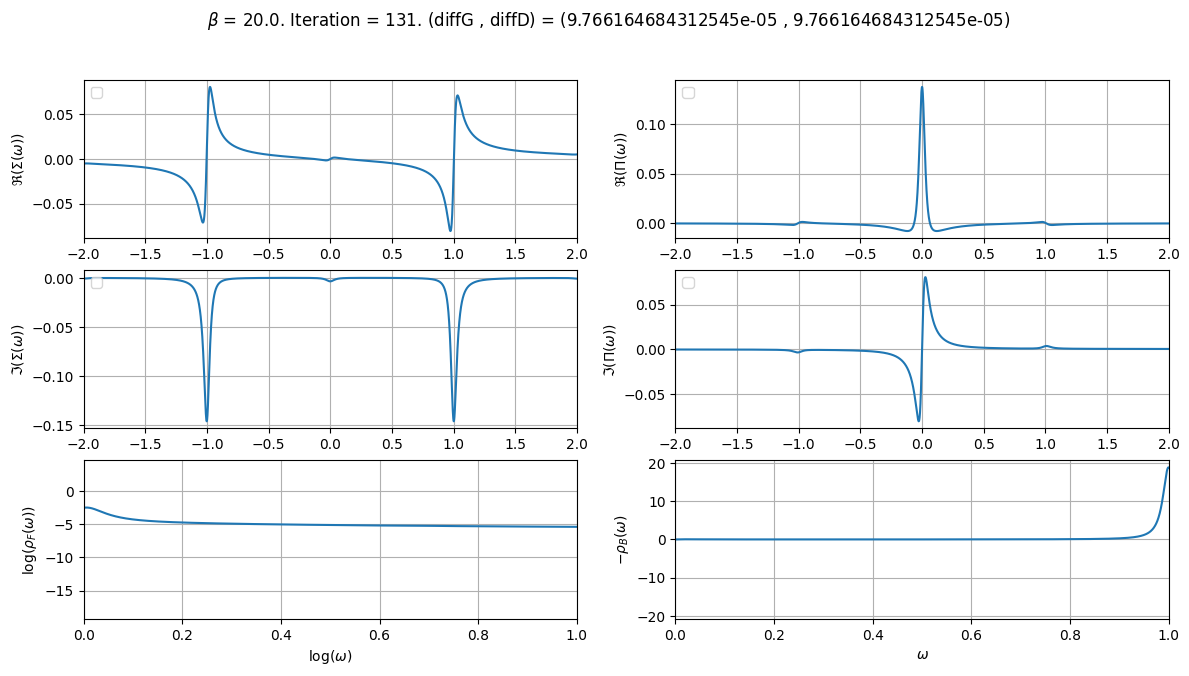

##### Finished beta =  20.0  in  131  iterations with diff =  9.766164684312545e-05  ############


In [4]:
ITERMAX = 15000 
#global beta

mu = 0.0
g = 0.5
m02 = 1.
eta = 30*dw
print("eta = ", eta)

#beta_start = 5
#beta = beta_start
#target_beta = 20
#beta_step = 1

betas = list(np.linspace(5, 20, 20))

#GRomega = CrazyGconfReal(omega + dw/2,g,betas[0],eta = eta)
#DRomega = CrazyDconfReal(omega + dw/2,g,betas[0],eta = eta)

GRomega = 1/(omega + 1j*eta + mu)
DRomega = 1/(-1.0*(omega + 1j*eta)**2 + m02)

grid = [M,omega,t]
pars = [g,mu,m02]

list_of_results = []
for beta in betas:
    print(fr'Current beta = {beta}. Starting iterator.')
    GRomega, DRomega, INFO = YSYK_0DNormaliterator(GRomega,DRomega,grid,pars,beta,err=err,ITERMAX=ITERMAX,eta = eta,epsilon = 0.05,slowly=True,midPointFlag=False) 
    list_of_results.append([GRomega,DRomega,beta])
    itern, diff = INFO
    #savefile = 'M' + str(int(np.log2(M))) + 'T' + str(int(np.log2(T))) 
    #savefile += 'beta' + str((round(beta*100))/100.) 
    #savefile += 'g' + str(g) + 'r' + str(r) 
    #savefile = savefile.replace('.','_') 
    #savefile +=  '.npy' 
    # np.save(os.path.join(path_to_junk, savefile), np.array([GRomega,DRomega]))
    print("##### Finished beta = ", beta," in ", itern, " iterations with diff = ", diff, " ############")

/var/folders/v5/lyp8rgn51w5c0nhlxxmrn1w40000gn/T/ipykernel_8501/2074396863.py:3: RuntimeWarning: invalid value encountered in log
  plt.plot(np.log(omega[M+1:]),np.log(-np.imag(list_of_results[i][0][M+1:])),label = rf'$\beta = ${list_of_results[i][2]}')


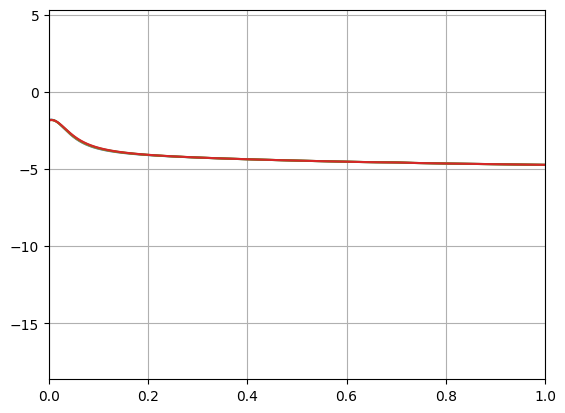

In [6]:
for i in range(0,len(list_of_results),5):
    #plt.plot(omega,np.imag(list_of_results[i][1]),label = rf'$\beta = ${list_of_results[i][2]}')
    plt.plot(np.log(omega[M+1:]),np.log(-np.imag(list_of_results[i][0][M+1:])),label = rf'$\beta = ${list_of_results[i][2]}')
plt.grid(True)
plt.xlim(0,1)
plt.show()

#### De-bugging

In [ ]:
ITERMAX = 15000 
global beta

mu = 0.0
g = 0.5
m02 = 1.
eta = 30*dw
print("eta = ", eta)

#beta_start = 5
#beta = beta_start
#target_beta = 20
#beta_step = 1

beta = 1

GRomega = 1/(omega + dw/2 + 1j*eta + mu)
DRomega = 1/(-1.0*(omega + dw/2 + 1j*eta)**2 + m02)

rhoG = -0.5*np.imag(GRomega)
rhoD = -0.5*np.imag(DRomega)

fig, axs = plt.subplots(nrows = 1,ncols = 2,figsize=(12,5))
axs[0].grid(True)
axs[0].set_xlabel(r'$\omega$')
axs[0].set_ylabel(r'$\rho(\omega)$')
axs[1].grid(True)
axs[1].set_xlabel(r'$\beta\omega$')
axs[1].set_ylabel(r'$\rho(\omega)$')
axs[0].plot(omega,rhoG,label = r'$\rho_G(\omega)$')
axs[0].plot(omega,rhoD,label = r'$\rho_D(\omega)$')
axs[0].set_xlim(-2,2)
axs[0].legend(loc='upper left')

fdplus = fermidirac_stable(beta*omega)
fdminus = fermidirac_stable(-1.0*beta*omega)
beplus = boseeinstein_stable(beta*(omega+dw*0.01)) #chequear si hay que modificar para evitar divergencia en x = 0
beminus = boseeinstein_stable(-1.0*beta*(omega+dw*0.01)) #ídem
BMf = [fdplus, fdminus, beplus, beminus]

axs[1].plot(beta*omega,fdplus, label = r'$n_{\mathrm{FD}}(\beta\omega)$')
axs[1].plot(beta*omega,fdminus, label = r'$n_{\mathrm{FD}}(-\beta\omega)$')
axs[1].plot(beta*omega,beplus, label = r'$n_{\mathrm{BE}}(\beta\omega)$')
axs[1].plot(beta*omega,beminus, label = r'$n_{\mathrm{BE}}(-\beta\omega)$')
axs[1].legend(loc = 'upper left')
axs[1].set_xlim(-0.025,0.025)
plt.show()

[Sigma1,Pi1] = rho2sigma0DNormal(rhoG,rhoD,M,dt,t,omega,g,beta,delta=1e-6,midPoint=True)
[Sigma2,Pi2] = rho2sigma0DNormal(rhoG,rhoD,M,dt,t,omega,g,beta,delta=1e-6,midPoint=False)





In [ ]:
[Sigma1,Pi1] = rho2sigma0DNormal(rhoG,rhoD,M,dt,t,omega,g,beta,delta=1e-6,midPoint=True)
[Sigma2,Pi2] = rho2sigma0DNormal(rhoG,rhoD,M,dt,t,omega,g,beta,delta=1e-6,midPoint=False)

fig, axs = plt.subplots(nrows = 2,ncols = 2,figsize=(12,6))
axs[0,0].set_xlabel(r'$\omega$')
axs[0,1].set_xlabel(r'$\omega$')
axs[0,0].set_ylabel(r'$\Re(\cdot)$')
axs[0,1].set_ylabel(r'$\Im(\cdot)$')
axs[1,0].set_xlabel(r'$\omega$')
axs[1,1].set_xlabel(r'$\omega$')
axs[1,0].set_ylabel(r'$\Re(\cdot)$')
axs[1,1].set_ylabel(r'$\Im(\cdot)$')

axs[0,0].plot(omega,np.real(Sigma1),label = r'$\Sigma_R^{\mathrm{m.p}}(\omega)$')
axs[0,0].plot(omega,np.real(Sigma2),label = r'$\Sigma_R(\omega)$',linestyle = 'dashed')
axs[0,1].plot(omega,np.real(Pi1),label = r'$\Pi_R^{\mathrm{m.p}}(\omega)$')
axs[0,1].plot(omega,np.real(Pi2),label = r'$\Pi_R(\omega)$',linestyle = 'dashed')

axs[1,0].plot(omega,np.imag(Sigma1),label = r'$\Sigma_R^{\mathrm{m.p}}(\omega)$')
axs[1,0].plot(omega,np.imag(Sigma2),label = r'$\Sigma_R(\omega)$',linestyle = 'dashed')
axs[1,1].plot(omega,np.imag(Pi1),label = r'$\Pi_R^{\mathrm{m.p}}(\omega)$')
axs[1,1].plot(omega,np.imag(Pi2),label = r'$\Pi_R(\omega)$',linestyle = 'dashed')

axs[0,0].legend(loc = 'upper left')
axs[0,1].legend(loc = 'upper left')
axs[1,0].legend(loc = 'upper left')
axs[1,1].legend(loc = 'upper left')

axs[0,0].set_xlim(-2,2)
axs[0,1].set_xlim(-2,2)
axs[1,0].set_xlim(-2,2)
axs[1,1].set_xlim(-2,2)
axs[0,0].grid(True)
axs[0,1].grid(True)
axs[1,0].grid(True)
axs[1,1].grid(True)
plt.tight_layout()
plt.show()


In [ ]:
epsilons = [0.01,0.1,0.5]
colors = ['red','blue','orange']

GRoldomega = GRomega
DRoldomega = DRomega

plt.figure(figsize=(12,6))
plt.grid(True)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho(\omega)$')
epsilon_handles = []
for j in range(0,len(epsilons)):
    GRomega = (2*epsilons[j])/(omega + dw/2 + 1j*eta + mu - Sigma1) + (1-2*epsilons[j])*GRoldomega
    DRomega = (2*epsilons[j])/(-1.0*(omega + dw/2+1j*eta)**2 + m02 - Pi1) + (1-2*epsilons[j])*DRoldomega
    rhoG = -0.5*np.imag(GRomega)
    #rhoD = -0.5*np.imag(DRomega)
    plt.plot(omega,rhoD,label = rf'$\epsilon = ${epsilons[j]}',color = colors[j])
    #plt.plot(omega,rhoD,color = 'orange')

plt.xlim(-2,2)
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
GRoriginal = GRoldomega
DRoriginal = DRoldomega

GRoldomega = (2*epsilons[1])/(omega + dw/2 + 1j*eta + mu - Sigma1) + (1-2*epsilons[1])*GRoldomega
DRoldomega = (2*epsilons[j])/(-1.0*(omega + dw/2+1j*eta)**2 + m02 - Pi1) + (1-2*epsilons[j])*DRoldomega

rhoG = -0.5*np.imag(GRoldomega)
rhoD = -0.5*np.imag(DRoldomega)

[Sigma1,Pi1] = rho2sigma0DNormal(rhoG,rhoD,M,dt,t,omega,g,beta,delta=1e-6,midPoint=True)
[Sigma2,Pi2] = rho2sigma0DNormal(rhoG,rhoD,M,dt,t,omega,g,beta,delta=1e-6,midPoint=False)

fig, axs = plt.subplots(nrows = 2,ncols = 2,figsize=(12,5))
axs[0,0].set_xlabel(r'$\omega$')
axs[0,1].set_xlabel(r'$\omega$')
axs[0,0].set_ylabel(r'$\Re(\cdot)$')
axs[0,1].set_ylabel(r'$\Im(\cdot)$')
axs[1,0].set_xlabel(r'$\omega$')
axs[1,1].set_xlabel(r'$\omega$')
axs[1,0].set_ylabel(r'$\Re(\cdot)$')
axs[1,1].set_ylabel(r'$\Im(\cdot)$')

axs[0,0].plot(omega,np.real(Sigma1),label = r'$\Sigma_R^{\mathrm{m.p}}(\omega)$')
axs[0,0].plot(omega,np.real(Sigma2),label = r'$\Sigma_R(\omega)$',linestyle = 'dashed')
axs[0,1].plot(omega,np.real(Pi1),label = r'$\Pi_R^{\mathrm{m.p}}(\omega)$')
axs[0,1].plot(omega,np.real(Pi2),label = r'$\Pi_R(\omega)$',linestyle = 'dashed')

axs[1,0].plot(omega,np.imag(Sigma1),label = r'$\Sigma_R^{\mathrm{m.p}}(\omega)$')
axs[1,0].plot(omega,np.imag(Sigma2),label = r'$\Sigma_R(\omega)$',linestyle = 'dashed')
axs[1,1].plot(omega,np.imag(Pi1),label = r'$\Pi_R^{\mathrm{m.p}}(\omega)$')
axs[1,1].plot(omega,np.imag(Pi2),label = r'$\Pi_R(\omega)$',linestyle = 'dashed')

axs[0,0].legend(loc = 'upper left')
axs[0,1].legend(loc = 'upper left')
axs[1,0].legend(loc = 'upper left')
axs[1,1].legend(loc = 'upper left')

axs[0,0].set_xlim(-2,2)
axs[0,1].set_xlim(-2,2)
axs[1,0].set_xlim(-2,2)
axs[1,1].set_xlim(-2,2)
axs[0,0].grid(True)
axs[0,1].grid(True)
axs[1,0].grid(True)
axs[1,1].grid(True)
plt.show()

In [ ]:
GRomega = (2*epsilons[1])/(omega + dw/2 + 1j*eta + mu - Sigma1) + (0.5-epsilons[1])*GRoldomega + (0.5-epsilons[1])*GRoriginal
DRomega = (2*epsilons[j])/(-1.0*(omega + dw/2+1j*eta)**2 + m02 - Pi1) + (0.5-epsilons[1])*DRoldomega + (0.5-epsilons[1])*DRoriginal


rhoG = -0.5*np.imag(GRomega)
rhoD = -0.5*np.imag(DRomega)

plt.figure(figsize=(12,6))
plt.grid(True)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\rho(\omega)$')
plt.grid(True)
plt.plot(omega,rhoG,label = r'$\rho_G(\omega)$')
plt.plot(omega,rhoD,label = r'$\rho_D(\omega)$')
plt.xlim(-2,2)
plt.legend(loc='upper left')
plt.show()

## Theory explanation for 2D-YSYK

---

### Normal state equations of motion

We should be ready, by now, to start writing our own version of the previous code writen by Aravindh, that will hopefully generalize to the two dimensional case of the YSYK model. First, we have to construct a bunch of numerical routines, and make sure we stick to a proper convention on signs and pre-factors of Fourier transforms. Then we must create an iterator that solves the Schwinger-Dyson equations numerically for the master fields of our theory, which will be the retarded Green's functions and self-energies of the fermionic and bosonic fields: $\Sigma$, $\Pi$, $G$ and $D$.

First of all, we state the euclidean action that we will take as base for our model, as is given in $[1]$, which represents a system of $N$-flavors of fermions coupled to $N$ flavors of bosons (represented by real scalar fields) on a square lattice:

$$
\begin{gather*}
S = \int_{0}^{\beta}\!\mathrm{d}\tau\iint\!\mathrm{d}^2\mathbf{x}\,\sum_{j=1}^N\sum_{\sigma=\pm1/2}\psi^\dagger_{j\sigma}(\tau,\mathbf{x})\left(\partial_\tau+\epsilon(i\nabla)-\mu\right)\psi_{j\sigma}(\tau,\mathbf{x})+\frac{1}{2}\int_0^\beta\!\mathrm{d}\tau\iint\!\,\mathrm{d}^2\mathbf{x}\,\sum_{j=1}^N\phi_j(\tau,\mathbf{x})(-\partial_\tau^2+\omega(i\nabla)^2)\phi_j(\tau,\mathbf{x})\\
+ \int_0^\beta\!\mathrm{d}\tau\iint\!\mathrm{d}^2\mathbf{x}\sum_{j,k=1}^N\sum_{\sigma=\pm1/2}\frac{v_{jk}(\mathbf{x})}{\sqrt{N}}\psi_{j\sigma}^\dagger(\tau,\mathbf{x})\psi_{j\sigma}(\tau,\mathbf{x})+\int_0^\beta\!\mathrm{d}\tau\iint\!\mathrm{d}^2\mathbf{x}\,\sum_{j,k,l=1}^{N}\sum_{\sigma=\pm1/2}\frac{g'_{jkl}(\mathbf{x})}{N}\psi_{j\sigma}^\dagger(\tau,\mathbf{x})\phi_{l}(\tau,\mathbf{x})\psi_{k\sigma}(\tau,\mathbf{x})
\end{gather*}
$$

The action includes specifically spatial disorder in the Yukawa coupling $g_{jkl}(\mathbf{x})$. This is in order to account for momentum relaxation in our model that may arise from electron scattering due to defects in the lattice that the Harris disorder we are considering aims to represent $[2]$, making this theory fundamentally different from any "pure" quantum critical system. In this case, implementing the fixed length contraint $[1,3]$ for tuning the system towards criticality: $\sum_q\sum_{j=1}^N\phi_{j,q}(\tau)\phi_{j,-q}(\tau)=N/\gamma$, we have the following Schwinger-Dyson equations for the normal state $[1,4]$:

$$
\begin{align*}
\Sigma(i\omega_n,\mathbf{x})&=v^2G(i\omega_n,\mathbf{x})\delta^{(2)}(\mathbf{x})+\frac{(g')^2}{\beta}\delta^{(2)}(\mathbf{x})\sum_{\nu_m} G(i\omega_n-i\nu_m,\mathbf{x})D(i\nu_m,\mathbf{x})\\
\Pi(i\nu_n,\mathbf{x})&=-\frac{2(g')^2}{\beta}\delta^{(2)}(\mathbf{x})\sum_{\omega_m}G(i\nu_n+i\omega_m,\mathbf{x})G(i\omega_m,\mathbf{x})\\
G(i\omega_n,\mathbf{x})&=\iint\frac{\mathrm{d}^2\mathbf{k}}{(2\pi)^2}\!\frac{e^{i\mathbf{k}\cdot\mathbf{x}}}{i\omega_n-\varepsilon(\mathbf{k})+\mu-\Sigma(i\omega_n,\mathbf{k})}\\
D(i\nu_n,\mathbf{x})&=\iint\frac{\mathrm{d}^2\mathbf{q}}{(2\pi)^2}\!\frac{e^{i\mathbf{q}\cdot\mathbf{x}}}{\nu_n^2+\omega(\mathbf{q})^2-\Pi(i\nu_n,\mathbf{k})}\\
\frac{1}{\gamma}&=\frac{1}{\beta}\sum_{\nu_m}\iint\!\frac{\mathrm{d}^2\mathbf{q}}{(2\pi)^2}\!\frac{1}{\nu_m^2+\omega(\mathbf{q})^2-\Pi(i\nu_m,\mathbf{q})}
\end{align*}
$$

Notice that the fact we are including only the spatially dependent Yukawa coupling makes the spatial Dirac delta functions $\delta^{(2)}(\mathbf{x})$ appear as overall factors in the first two Schwinger-Dyson equations. This simplifies considerably the work we must do, since the self-energies and Green's functions will therefore be uniform functions in spatial momentum space. As such, we can re-write the Schwinger-Dyson equations in the following manner:
$$
\begin{align*}
\Sigma(i\omega_n,\mathbf{x})&=v^2G(i\omega_n,\mathbf{x}=\mathbf{0})\delta^{(2)}(\mathbf{x})+\frac{(g')^2}{\beta}\delta^{(2)}(\mathbf{x})\sum_{\nu_m} G(i\omega_n-i\nu_m,\mathbf{x}=\mathbf{0})D(i\nu_m,\mathbf{x}=\mathbf{0})\\
\Pi(i\nu_n,\mathbf{x})&=-\frac{2(g')^2}{\beta}\delta^{(2)}(\mathbf{x})\sum_{\omega_m}G(i\nu_n+i\omega_m,\mathbf{x}=\mathbf{0})G(i\omega_m,\mathbf{x}=\mathbf{0})\\
G(i\omega_n,\mathbf{x}=\mathbf{0})&=\iint\frac{\mathrm{d}^2\mathbf{k}}{(2\pi)^2}\!\frac{1}{i\omega_n-\varepsilon(\mathbf{k})+\mu-\Sigma(i\omega_n)}\\
D(i\nu_n,\mathbf{x}=\mathbf{0})&=\iint\frac{\mathrm{d}^2\mathbf{q}}{(2\pi)^2}\!\frac{1}{\nu_n^2+\omega(\mathbf{q})^2-\Pi(i\nu_n)}\\
\frac{1}{\gamma}&=\frac{1}{\beta}\sum_{\nu_m}\iint\!\frac{\mathrm{d}^2\mathbf{q}}{(2\pi)^2}\!\frac{1}{\nu_m^2+\omega(\mathbf{q})^2-\Pi(i\nu_m)}
\end{align*},
$$
where we have denoted by $\Pi(i\nu_n)\equiv\Pi(i\nu_n,\mathbf{k})$ and $\Sigma(i\omega_n)\equiv\Sigma(i\omega_n)$ the uniform-in-momentum Fourier transforms of the self-energies. To simplify notation even further, we define the following:
$$
G(i\omega_n)\equiv G(i\omega_n,\mathbf{x}=\mathbf{0})\,,\,D(i\nu_n)\equiv D(i\nu_n)
$$
Therefore, the Schwinger-Dyson equations simplify all the way to being exclusively set in Matsubara frequency space, just as they were in the case of the $0+1$-dimensional YSYK quantum dot model:
$$
\begin{align*}
\Sigma(i\omega_n)&=v^2G(i\omega_n)+\frac{(g')^2}{\beta}\sum_{\nu_m} G(i\omega_n-i\nu_m)D(i\nu_m)\\
\Pi(i\nu_n)&=-\frac{2(g')^2}{\beta}\sum_{\omega_m}G(i\nu_n+i\omega_m)G(i\omega_m)\\
G(i\omega_n)&=\iint\frac{\mathrm{d}^2\mathbf{k}}{(2\pi)^2}\!\frac{1}{i\omega_n-\varepsilon(\mathbf{k})+\mu-\Sigma(i\omega_n)}\\
D(i\nu_n)&=\iint\frac{\mathrm{d}^2\mathbf{q}}{(2\pi)^2}\!\frac{1}{\nu_n^2+\omega(\mathbf{q})^2-\Pi(i\nu_n)}\\
\frac{1}{\gamma}&=\frac{1}{\beta}\sum_{\nu_m}\iint\!\frac{\mathrm{d}^2\mathbf{q}}{(2\pi)^2}\!\frac{1}{\nu_m^2+\omega(\mathbf{q})^2-\Pi(i\nu_m)}
\end{align*},
$$

The dispersion relations that we use for fermions and bosons are, respectively, those that come from a square lattice:
$$
\begin{align*}
\varepsilon(\mathbf{k})&=-2t(\cos k_x+\cos k_y)\\
\omega(\mathbf{q})^2&=\omega_0^2+2J(2-\cos q_x-\cos q_y).
\end{align*}
$$
The parameter $t$ is the inter-lattice site hopping parameter, and the $J$ constant in the boson dispersion relation is the coupling constant between bosons on each site. On the other hand, the constants that $(g')^2$ and $v^2$ that show up in the equations of motion correspond to the averages of the random Yukawa coupling and inter-fermionic potentials over their corresponding ensenmbles:
$$
\begin{align*}
\langle\,g'_{jkl}(\mathbf{x})\,g'_{j'k'l'}(\mathbf{x}')\,\rangle&= (g')^2\delta(\mathbf{x}-\mathbf{x}')\delta(\mathbf{x}-\mathbf{x}')\delta_{jj'}\delta_{kk'}\delta_{ll'}\\
\langle\,v_{jk}(\mathbf{x})^*\,v_{j'k'}(\mathbf{x}')\rangle&=v^2\delta(\mathbf{x}-\mathbf{x}')\delta_{jj'}\delta_{kk'}
\end{align*}
$$

Since we are working with a lattice system, special care must be taken when understanding the meaning of the Fourier integrals in spatial momentum space. Indeed, before taking the thermodynamic limit, the system is defined over a two-dimensional square lattice (with generic lattice constant $a$). The system has translational symmetry broken down to the discrete subgroup of lattice translations, with the Bravais lattice itself defined as the set of points:
$$
\mathcal{L} = \left\{\mathbf{R}\in\mathbb{R}^2\,\colon\;\exists\,n_1,\,n_2\in\mathbb{Z}\;\text{s.t}\;\mathbf{R}=n_1\cdot a\hat{\mathbf{x}}+n_2\cdot a\hat{\mathbf{y}}\right\}=\mathrm{span}_{\,\mathbb{Z}}\{a\hat{\mathbf{x}},a\hat{\mathbf{y}}\}\equiv \mathbb{Z}^2\cdot\mathcal{L}_1,
$$
where we have denoted by $\mathcal{L}_1$ the lattice's unit cell containing $\mathbf{R} = \mathbf{0}$.

Since we are working with a lattice action, the momentum quantum number of the quantum fields is discretized, and restricted to, the first Brillouin zone of the reciprocal lattice. For the square lattice, its reciprocal lattice is simply:
$$
\mathcal{L}'=\left\{\mathbf{K}\in\mathbb{R}^2\;\colon\;\exists\,n_1,n_2\in\mathbb{Z}\;\text{s.t}\;\mathbf{K}=n_1\cdot\frac{2\pi}{a}\hat{\mathbf{x}}+n_2\cdot\frac{2\pi}{a}\hat{\mathbf{y}}\right\}
$$

The above statement can easily be justified by recalling that in these types of solid-state systems we impose Born-von Karman boundary conditions at the edges of the solid, which implies that all functions $f(\mathbf{x})$ that respect these boundary conditions (including the Green's functions) can be decomposed in a Fourier series over crystal momentum eigenstates of the periodic Hamiltonian:
$$
\mathbf{k}\equiv\mathbf{k}_{n_1,n_2}=\frac{2\pi n_1}{aN_x}\cdot\hat{\mathbf{x}}+\frac{2\pi n_2}{aN_y}\cdot\hat{\mathbf{y}},
$$ 
with $N_x$ the amount of unit cells in the material's $x$-direction, and $N_y$ the amount of unit cells in the material's $y$-direction. These momentum vectors are confined to be in the first Brillouin zone of the reciprocal lattice, and so a function $f(\mathbf{x})$ that respects BvK boundary conditions can be expressed as:
$$
f(\mathbf{x})=\sum_{\mathbf{k}\in\mathcal{BZ}_1}e^{i\mathbf{k}\cdot\mathbf{x}}f(\mathbf{k})
$$

In the thermodynamic limit, the size of the sistem ($L = a^2N_xN_y$) tends to infinity when compared to the size of the crystal's unit cell: $L/a^2\to\infty$. This implies taking $N_x,N_y\to\infty$, while also:
$$
f(\mathbf{x})\underset{L\to\infty}{\longmapsto} L\iint_{\mathcal{BZ}_1}\!\frac{\mathrm{d}^2\mathbf{k}}{(2\pi)^2}e^{i\mathbf{k\cdot\mathbf{x}}}f(\mathbf{k}).
$$

## References

- $[1]$ Li, C., Valentinis, D., Patel, A.A., Guo, H., Schmalian, J., Sachdev, S. & Esterlis, I. (2024). Strange metal and superconductor in the two-dimensional Yukawa-Scahdev-Ye-Kitaev model. *Phys. Rev. Lett.* **133**, 189502. DOI: 10.1103/PhysRevLett.133.186502.

- $[2]$ Patel, A.A., Guo, H., Esterlis, I. & Sachdev, S. (2023). Universal theory of strange metals from spatially random interactions. *Science* **381**, 790-793. DOI: 10.1126/science.abq6011

- $[3]$ Esterlis, I., Guo, H., Patel, A.A., Sachdev, S. (2021). Large-$N$ theory of critical Fermi surfaces. *Phys. Rev. B.* **103**, 235129. DOI: 10.1103/PhysRevB.103.235129

- $[4]$ Sachdev, S. (2024, August $20^{\mathrm{th}}$). *Lectures on the quantum phase transitions of metals* [lecture notes]. arXiv: https://arxiv.org/abs/2407.15919.

- $[5]$ Esterlis, I. & Schmalian, J. (2019). Cooper pairing of incoherent electrons: An electron-phonon version of the Sachdev-Ye-Kitaev model. *Phys. Rev. B.* **100**, 115132. DOI: 10.1103/PhysRevB.100.115132

- $[6]$ Shankar, A.S., Steenbergen, J., Plugge, S. & Schalm, K. (2025). A Josephson wormhole in coupled superconducting Yukawa-SYK metals. *Phys. Rev. Res.* **8**, 013112. DOI: 10.1103/v2gn-I936